# TFT Ablation Study Notebook

Notebook ini dibuat untuk menjalankan ablation study pada model **Temporal Fusion Transformer (TFT) One-Step** dengan preprocessing dan konfigurasi yang disamakan dengan `modeling.ipynb`.

Ablation yang dijalankan hanya menghapus feature group contextual yang memang dipakai oleh TFT final:

| Case | Experiment | Description |
|---:|---|---|
| 1 | `TFT_Full_Baseline` | Tidak retrain. Membaca hasil TFT full dari output notebook sebelumnya jika tersedia. |
| 2 | `TFT_No_Weather` | Menghapus weather features. |
| 3 | `TFT_No_Calendar` | Menghapus calendar/seasonality features. |
| 4 | `TFT_No_Holiday` | Menghapus holiday features. |
| 5 | `TFT_Target_History_Only` | Hanya memakai `time_idx` sebagai known real; histori target tetap masuk lewat encoder `model_target_mw`. |

Catatan metodologi: explicit lag/rolling features tidak dimasukkan sebagai ablation group karena TFT final pada `modeling.ipynb` tidak memakai fitur tersebut secara eksplisit. TFT sudah menangkap histori load melalui encoder sequence `model_target_mw` sepanjang 168 jam.

In [ ]:
# ============================================================
# Optional installation
# ============================================================
# Jalankan cell ini hanya kalau environment belum punya package terkait.
# !pip install lightning pytorch-forecasting torch scikit-learn pandas numpy matplotlib

In [1]:
# ============================================================
# Imports
# ============================================================

import os
import json
import random
import time
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from lightning.pytorch import Trainer, seed_everything
from lightning.pytorch.callbacks import EarlyStopping, LearningRateMonitor
from lightning.pytorch.loggers import CSVLogger

from pytorch_forecasting import TimeSeriesDataSet, TemporalFusionTransformer
from pytorch_forecasting.metrics import RMSE
from pytorch_forecasting.data import GroupNormalizer

In [2]:
# ============================================================
# User Configuration
# ============================================================

# Change this variable to assign which ablation case to run.
# Available options:
#   [2]       -> run only Case 2: TFT_No_Weather
#   [3]       -> run only Case 3: TFT_No_Calendar
#   [4]       -> run only Case 4: TFT_No_Holiday
#   [5]       -> run only Case 5: TFT_Target_History_Only
#   [2, 3, 4, 5] -> run all ablation cases
CASES_TO_RUN = [3]

# Main input dataset, same as modeling.ipynb
DATA_PATH = "merge_outputs/all_features_all_timerange.csv"

# Output locations
OUTPUT_DIR = "modeling_outputs"
ABLATION_OUTPUT_DIR = "modeling_outputs/tft_ablation"
ABLATION_MODEL_DIR = "modeling_outputs/tft_ablation/saved_models"
ABLATION_LOG_DIR = "modeling_outputs/tft_ablation/logs"

os.makedirs(OUTPUT_DIR, exist_ok=True)
os.makedirs(ABLATION_OUTPUT_DIR, exist_ok=True)
os.makedirs(ABLATION_MODEL_DIR, exist_ok=True)
os.makedirs(ABLATION_LOG_DIR, exist_ok=True)

# Training configuration, matched to modeling.ipynb
RANDOM_STATE = 42
MAX_EPOCHS = 20
BATCH_SIZE = 128
NUM_WORKERS = 0

# TFT architecture and optimization, matched to modeling.ipynb
TFT_PARAMS = {
    "learning_rate": 0.03,
    "hidden_size": 16,
    "attention_head_size": 2,
    "dropout": 0.1,
    "hidden_continuous_size": 8,
    "loss": RMSE(),
    "optimizer": "adam",
    "reduce_on_plateau_patience": 3,
}

# TimeSeriesDataSet setup, matched to modeling.ipynb
MAX_ENCODER_LENGTH = 168
MAX_PREDICTION_LENGTH = 1
STATIC_CATEGORICALS = ["Region"]
TARGET_COLUMN = "model_target_mw"
GROUP_IDS = ["Region"]

print("Cases to run:", CASES_TO_RUN)
print("Data path:", DATA_PATH)

Cases to run: [3]
Data path: merge_outputs/all_features_all_timerange.csv


In [3]:
# ============================================================
# Load Dataset
# ============================================================

if not os.path.exists(DATA_PATH):
    raise FileNotFoundError(
        f"DATA_PATH not found: {DATA_PATH}\n"
        "Make sure you run this notebook from the project root folder, "
        "or change DATA_PATH to the correct file location."
    )

df = pd.read_csv(DATA_PATH)

print("Dataset shape:", df.shape)
df.head()

Dataset shape: (95088, 60)


,timestamp_utc,Region,data_date,region_demand_mw,region_demand_forecast_mw,num_ba,num_rows,num_available_ba,num_missing_ba,year,...,cooling_degree,heating_degree,temp_squared,lag_1h,lag_24h,lag_168h,rolling_mean_24h,rolling_mean_168h,rolling_std_24h,rolling_std_168h
0,2015-07-01 08:00:00+00:00,CAL,2015-07-01,38210.0,35264.0,5,5,5,0,2015,...,5.2,0.0,552.25,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2015-07-01 09:00:00+00:00,CAL,2015-07-01,35171.0,32894.0,5,5,5,0,2015,...,4.3,0.0,510.76,38210.0,NaN,NaN,NaN,NaN,NaN,NaN
2,2015-07-01 10:00:00+00:00,CAL,2015-07-01,33243.0,31360.0,5,5,5,0,2015,...,3.4,0.0,470.89,35171.0,NaN,NaN,NaN,NaN,NaN,NaN
3,2015-07-01 11:00:00+00:00,CAL,2015-07-01,31955.0,30579.0,5,5,5,0,2015,...,3.0,0.0,453.69,33243.0,NaN,NaN,NaN,NaN,NaN,NaN
4,2015-07-01 12:00:00+00:00,CAL,2015-07-01,31199.0,30723.0,5,5,5,0,2015,...,2.9,0.0,449.44,31955.0,NaN,NaN,NaN,NaN,NaN,NaN


In [4]:
# ============================================================
# Preprocessing: Matched with modeling.ipynb
# ============================================================

df_model = df.copy()

# Datetime columns
df_model["timestamp_utc"] = pd.to_datetime(df_model["timestamp_utc"], utc=True)
df_model["data_date"] = pd.to_datetime(df_model["data_date"])

if "timestamp_local" in df_model.columns:
    df_model["timestamp_local"] = df_model["timestamp_utc"].dt.tz_convert("America/Los_Angeles")

if "local_date" in df_model.columns:
    df_model["local_date"] = pd.to_datetime(df_model["local_date"])

# Binary columns for modeling
binary_cols = [
    "is_weekend",
    "is_holiday",
    "is_day_before_holiday",
    "is_day_after_holiday",
    "is_holiday_period",
]

for col in binary_cols:
    if col in df_model.columns:
        df_model[col] = df_model[col].map({
            "No": 0,
            "Yes": 1,
            0: 0,
            1: 1,
            False: 0,
            True: 1
        }).astype("int8")

df_model = df_model.sort_values("timestamp_utc").reset_index(drop=True)

print("Preprocessed df_model shape:", df_model.shape)
print("Date range:", df_model["timestamp_utc"].min(), "to", df_model["timestamp_utc"].max())

Preprocessed df_model shape: (95088, 60)
Date range: 2015-07-01 08:00:00+00:00 to 2026-05-06 07:00:00+00:00


In [5]:
# ============================================================
# Split Boundaries: Matched with modeling.ipynb
# ============================================================

warmup_start_date = pd.Timestamp("2015-07-01")
modeling_start_date = pd.Timestamp("2017-07-01")

train_end_date = pd.Timestamp("2024-01-01")
valid_end_date = pd.Timestamp("2025-01-01")
test_end_date = pd.Timestamp("2026-05-07")

warmup_df = df_model[
    (df_model["data_date"] >= warmup_start_date) &
    (df_model["data_date"] < modeling_start_date)
].copy()

train_df = df_model[
    (df_model["data_date"] >= modeling_start_date) &
    (df_model["data_date"] < train_end_date)
].copy()

valid_df = df_model[
    (df_model["data_date"] >= train_end_date) &
    (df_model["data_date"] < valid_end_date)
].copy()

test_df = df_model[
    (df_model["data_date"] >= valid_end_date) &
    (df_model["data_date"] < test_end_date)
].copy()

print("Warm-up:", warmup_df.shape, warmup_df["timestamp_utc"].min(), "to", warmup_df["timestamp_utc"].max())
print("Train:", train_df.shape, train_df["timestamp_utc"].min(), "to", train_df["timestamp_utc"].max())
print("Validation:", valid_df.shape, valid_df["timestamp_utc"].min(), "to", valid_df["timestamp_utc"].max())
print("Test:", test_df.shape, test_df["timestamp_utc"].min(), "to", test_df["timestamp_utc"].max())

Warm-up: (17544, 60) 2015-07-01 08:00:00+00:00 to 2017-07-01 07:00:00+00:00
Train: (57001, 60) 2017-07-01 08:00:00+00:00 to 2024-01-01 08:00:00+00:00
Validation: (8784, 60) 2024-01-01 09:00:00+00:00 to 2025-01-01 08:00:00+00:00
Test: (11759, 60) 2025-01-01 09:00:00+00:00 to 2026-05-06 07:00:00+00:00


In [6]:
# ============================================================
# Build TFT Dataset Frame: Matched with modeling.ipynb
# ============================================================

df_tft = df_model.copy()

df_tft["timestamp_utc"] = pd.to_datetime(df_tft["timestamp_utc"], utc=True)
df_tft["data_date"] = pd.to_datetime(df_tft["data_date"])

df_tft = df_tft.sort_values("timestamp_utc").reset_index(drop=True)

# Continuous hourly time index
df_tft["time_idx"] = (
    (df_tft["timestamp_utc"] - df_tft["timestamp_utc"].min())
    .dt.total_seconds() // 3600
).astype(int)

# Group identifier
df_tft["Region"] = df_tft["Region"].astype(str)

# TFT target:
# - before 2024-01-01: use imputed/causal training target
# - validation/test period: use actual region demand
# This follows modeling.ipynb exactly.
df_tft["model_target_mw"] = np.where(
    df_tft["data_date"] < pd.Timestamp("2024-01-01"),
    df_tft["target_region_demand_mw"],
    df_tft["region_demand_mw"]
)

# Drop rows without target for TFT dataset construction
df_tft = df_tft.dropna(subset=["model_target_mw"]).copy()

print("TFT dataset shape:", df_tft.shape)
print("Missing model target:", df_tft["model_target_mw"].isna().sum())
print("Time index range:", df_tft["time_idx"].min(), "to", df_tft["time_idx"].max())
df_tft.head()

TFT dataset shape: (95088, 62)
Missing model target: 0
Time index range: 0 to 95087


,timestamp_utc,Region,data_date,region_demand_mw,region_demand_forecast_mw,num_ba,num_rows,num_available_ba,num_missing_ba,year,...,temp_squared,lag_1h,lag_24h,lag_168h,rolling_mean_24h,rolling_mean_168h,rolling_std_24h,rolling_std_168h,time_idx,model_target_mw
0,2015-07-01 08:00:00+00:00,CAL,2015-07-01,38210.0,35264.0,5,5,5,0,2015,...,552.25,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,38210.0
1,2015-07-01 09:00:00+00:00,CAL,2015-07-01,35171.0,32894.0,5,5,5,0,2015,...,510.76,38210.0,NaN,NaN,NaN,NaN,NaN,NaN,1,35171.0
2,2015-07-01 10:00:00+00:00,CAL,2015-07-01,33243.0,31360.0,5,5,5,0,2015,...,470.89,35171.0,NaN,NaN,NaN,NaN,NaN,NaN,2,33243.0
3,2015-07-01 11:00:00+00:00,CAL,2015-07-01,31955.0,30579.0,5,5,5,0,2015,...,453.69,33243.0,NaN,NaN,NaN,NaN,NaN,NaN,3,31955.0
4,2015-07-01 12:00:00+00:00,CAL,2015-07-01,31199.0,30723.0,5,5,5,0,2015,...,449.44,31955.0,NaN,NaN,NaN,NaN,NaN,NaN,4,31199.0


In [7]:
# ============================================================
# TFT Split Index: Matched with modeling.ipynb
# ============================================================

train_max_time_idx = df_tft.loc[
    df_tft["data_date"] < train_end_date,
    "time_idx"
].max()

valid_start_time_idx = df_tft.loc[
    df_tft["data_date"] >= train_end_date,
    "time_idx"
].min()

test_start_time_idx = df_tft.loc[
    df_tft["data_date"] >= valid_end_date,
    "time_idx"
].min()

print("Train max time_idx:", train_max_time_idx)
print("Validation start time_idx:", valid_start_time_idx)
print("Test start time_idx:", test_start_time_idx)

Train max time_idx: 74544
Validation start time_idx: 74545
Test start time_idx: 83329


In [8]:
# ============================================================
# Feature Groups for TFT Ablation
# ============================================================

base_features = ["time_idx"]

weather_features = [
    "temperature_2m",
    "relative_humidity_2m",
    "wind_speed_10m",
    "precipitation",
    "cooling_degree",
    "heating_degree",
    "temp_squared",
]

calendar_features = [
    "hour_sin",
    "hour_cos",
    "day_of_week_sin",
    "day_of_week_cos",
    "month_sin",
    "month_cos",
    "day_of_year_sin",
    "day_of_year_cos",
]

holiday_features = [
    "is_weekend",
    "is_holiday",
    "is_day_before_holiday",
    "is_day_after_holiday",
    "is_holiday_period",
]

# Keep only existing columns in df_tft
weather_features = [col for col in weather_features if col in df_tft.columns]
calendar_features = [col for col in calendar_features if col in df_tft.columns]
holiday_features = [col for col in holiday_features if col in df_tft.columns]

full_known_reals = base_features + weather_features + calendar_features + holiday_features

case_config = {
    1: {
        "experiment": "TFT_Full_Baseline",
        "known_reals": full_known_reals,
        "description": "Full TFT baseline from previous modeling.ipynb output; not retrained in this notebook by default.",
        "train": False,
    },
    2: {
        "experiment": "TFT_No_Weather",
        "known_reals": base_features + calendar_features + holiday_features,
        "description": "Remove weather features.",
        "train": True,
    },
    3: {
        "experiment": "TFT_No_Calendar",
        "known_reals": base_features + weather_features + holiday_features,
        "description": "Remove calendar and seasonality features.",
        "train": True,
    },
    4: {
        "experiment": "TFT_No_Holiday",
        "known_reals": base_features + weather_features + calendar_features,
        "description": "Remove holiday features.",
        "train": True,
    },
    5: {
        "experiment": "TFT_Target_History_Only",
        "known_reals": base_features,
        "description": "Use only time_idx as known real. Historical target still enters through encoder model_target_mw.",
        "train": True,
    },
}

print("Weather features:", len(weather_features), weather_features)
print("Calendar features:", len(calendar_features), calendar_features)
print("Holiday features:", len(holiday_features), holiday_features)
print("Full known reals:", len(full_known_reals), full_known_reals)

for case_id, cfg in case_config.items():
    print("=" * 80)
    print(f"Case {case_id}: {cfg['experiment']}")
    print(cfg["description"])
    print("Train in this notebook:", cfg["train"])
    print("Known reals:", len(cfg["known_reals"]), cfg["known_reals"])

Weather features: 7 ['temperature_2m', 'relative_humidity_2m', 'wind_speed_10m', 'precipitation', 'cooling_degree', 'heating_degree', 'temp_squared']
Calendar features: 8 ['hour_sin', 'hour_cos', 'day_of_week_sin', 'day_of_week_cos', 'month_sin', 'month_cos', 'day_of_year_sin', 'day_of_year_cos']
Holiday features: 5 ['is_weekend', 'is_holiday', 'is_day_before_holiday', 'is_day_after_holiday', 'is_holiday_period']
Full known reals: 21 ['time_idx', 'temperature_2m', 'relative_humidity_2m', 'wind_speed_10m', 'precipitation', 'cooling_degree', 'heating_degree', 'temp_squared', 'hour_sin', 'hour_cos', 'day_of_week_sin', 'day_of_week_cos', 'month_sin', 'month_cos', 'day_of_year_sin', 'day_of_year_cos', 'is_weekend', 'is_holiday', 'is_day_before_holiday', 'is_day_after_holiday', 'is_holiday_period']
Case 1: TFT_Full_Baseline
Full TFT baseline from previous modeling.ipynb output; not retrained in this notebook by default.
Train in this notebook: False
Known reals: 21 ['time_idx', 'temperature_

In [9]:
# ============================================================
# Validate Selected Cases
# ============================================================

if isinstance(CASES_TO_RUN, int):
    CASES_TO_RUN = [CASES_TO_RUN]

invalid_cases = [case for case in CASES_TO_RUN if case not in case_config]
if invalid_cases:
    raise ValueError(f"Invalid cases: {invalid_cases}. Valid options are: {list(case_config.keys())}")

# This notebook is intended for Cases 2-5. Case 1 is allowed only for reading baseline output.
print("Selected cases:")
for case in CASES_TO_RUN:
    cfg = case_config[case]
    print(f"Case {case}: {cfg['experiment']} -> {cfg['description']}")

Selected cases:
Case 3: TFT_No_Calendar -> Remove calendar and seasonality features.


In [10]:
# ============================================================
# Evaluation Helpers
# ============================================================

def evaluate_regression(y_true, y_pred):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)

    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)

    nonzero_mask = y_true != 0
    mape = np.mean(np.abs((y_true[nonzero_mask] - y_pred[nonzero_mask]) / y_true[nonzero_mask])) * 100

    return {
        "MAE": mae,
        "RMSE": rmse,
        "MAPE": mape,
        "R2": r2,
    }


def extract_actuals_from_dataloader(dataloader):
    actuals = []

    for x, y in dataloader:
        if isinstance(y, tuple):
            y = y[0]
        actuals.append(y.detach().cpu())

    return torch.cat(actuals, dim=0)

In [11]:
# ============================================================
# Dataset and Dataloader Builder
# ============================================================

def build_tft_datasets_and_loaders(known_reals):
    # Build TimeSeriesDataSet and dataloaders using the same setup as modeling.ipynb.
    # Only time_varying_known_reals changes depending on the ablation case.

    training = TimeSeriesDataSet(
        df_tft[df_tft["data_date"] < train_end_date],
        time_idx="time_idx",
        target=TARGET_COLUMN,
        group_ids=GROUP_IDS,

        max_encoder_length=MAX_ENCODER_LENGTH,
        max_prediction_length=MAX_PREDICTION_LENGTH,

        static_categoricals=STATIC_CATEGORICALS,

        time_varying_known_reals=known_reals,

        time_varying_unknown_reals=[
            TARGET_COLUMN
        ],

        target_normalizer=GroupNormalizer(
            groups=GROUP_IDS,
            transformation="softplus"
        ),

        allow_missing_timesteps=True,
        add_relative_time_idx=True,
        add_target_scales=True,
        add_encoder_length=True,
    )

    validation = TimeSeriesDataSet.from_dataset(
        training,
        df_tft[df_tft["data_date"] < valid_end_date],
        min_prediction_idx=valid_start_time_idx,
        stop_randomization=True
    )

    test = TimeSeriesDataSet.from_dataset(
        training,
        df_tft[df_tft["data_date"] < test_end_date],
        min_prediction_idx=test_start_time_idx,
        stop_randomization=True
    )

    train_dataloader = training.to_dataloader(
        train=True,
        batch_size=BATCH_SIZE,
        num_workers=NUM_WORKERS
    )

    valid_dataloader = validation.to_dataloader(
        train=False,
        batch_size=BATCH_SIZE,
        num_workers=NUM_WORKERS
    )

    test_dataloader = test.to_dataloader(
        train=False,
        batch_size=BATCH_SIZE,
        num_workers=NUM_WORKERS
    )

    return training, validation, test, train_dataloader, valid_dataloader, test_dataloader

In [12]:
# ============================================================
# Run One TFT Ablation Experiment
# ============================================================

def run_tft_ablation_case(case_id):
    cfg = case_config[case_id]
    experiment_name = cfg["experiment"]
    known_reals = cfg["known_reals"]

    if not cfg["train"]:
        raise ValueError(
            f"Case {case_id} ({experiment_name}) is a baseline-reading case and is not trained here. "
            "Use Cases 2-5 for ablation training."
        )

    print("\n" + "=" * 100)
    print(f"Running Case {case_id}: {experiment_name}")
    print("=" * 100)
    print(cfg["description"])
    print("Known real features:", len(known_reals), known_reals)

    seed_everything(RANDOM_STATE, workers=True)
    random.seed(RANDOM_STATE)
    np.random.seed(RANDOM_STATE)
    torch.manual_seed(RANDOM_STATE)

    (
        training,
        validation,
        test,
        train_dataloader,
        valid_dataloader,
        test_dataloader,
    ) = build_tft_datasets_and_loaders(known_reals)

    print("Training batches:", len(train_dataloader))
    print("Validation batches:", len(valid_dataloader))
    print("Test batches:", len(test_dataloader))

    tft = TemporalFusionTransformer.from_dataset(
        training,
        **TFT_PARAMS,
    )

    print(f"Number of parameters: {tft.size() / 1e3:.1f}k")

    early_stop_callback = EarlyStopping(
        monitor="val_loss",
        min_delta=1e-4,
        patience=5,
        verbose=True,
        mode="min"
    )

    lr_logger = LearningRateMonitor()

    logger = CSVLogger(
        save_dir=ABLATION_LOG_DIR,
        name=experiment_name
    )

    trainer = Trainer(
        max_epochs=MAX_EPOCHS,
        accelerator="auto",
        devices="auto",
        gradient_clip_val=0.1,
        callbacks=[early_stop_callback, lr_logger],
        logger=logger,
        enable_model_summary=True,
    )

    start_time = time.time()

    trainer.fit(
        tft,
        train_dataloaders=train_dataloader,
        val_dataloaders=valid_dataloader
    )

    elapsed_seconds = time.time() - start_time

    valid_pred = tft.predict(valid_dataloader)
    test_pred = tft.predict(test_dataloader)

    valid_actual = extract_actuals_from_dataloader(valid_dataloader)
    test_actual = extract_actuals_from_dataloader(test_dataloader)

    valid_pred_np = valid_pred.detach().cpu().numpy().reshape(-1)
    test_pred_np = test_pred.detach().cpu().numpy().reshape(-1)

    valid_actual_np = valid_actual.detach().cpu().numpy().reshape(-1)
    test_actual_np = test_actual.detach().cpu().numpy().reshape(-1)

    valid_metrics = evaluate_regression(valid_actual_np, valid_pred_np)
    test_metrics = evaluate_regression(test_actual_np, test_pred_np)

    result_df = pd.DataFrame([
        {
            "case_id": case_id,
            "model": experiment_name,
            "split": "validation",
            "n_rows": len(valid_actual_np),
            "n_known_real_features": len(known_reals),
            "known_real_features": ", ".join(known_reals),
            "elapsed_seconds": elapsed_seconds,
            **valid_metrics,
        },
        {
            "case_id": case_id,
            "model": experiment_name,
            "split": "test",
            "n_rows": len(test_actual_np),
            "n_known_real_features": len(known_reals),
            "known_real_features": ", ".join(known_reals),
            "elapsed_seconds": elapsed_seconds,
            **test_metrics,
        }
    ])

    prediction_df = pd.DataFrame({
        "actual": test_actual_np,
        "prediction": test_pred_np,
        "error": test_actual_np - test_pred_np,
        "absolute_error": np.abs(test_actual_np - test_pred_np),
    })

    checkpoint_path = os.path.join(ABLATION_MODEL_DIR, f"{experiment_name}.ckpt")
    trainer.save_checkpoint(checkpoint_path)

    result_path = os.path.join(ABLATION_OUTPUT_DIR, f"{experiment_name}_results.csv")
    pred_path = os.path.join(ABLATION_OUTPUT_DIR, f"{experiment_name}_test_predictions.csv")
    metadata_path = os.path.join(ABLATION_OUTPUT_DIR, f"{experiment_name}_metadata.json")

    result_df.to_csv(result_path, index=False)
    prediction_df.to_csv(pred_path, index=False)

    metadata = {
        "case_id": case_id,
        "experiment": experiment_name,
        "description": cfg["description"],
        "data_path": DATA_PATH,
        "max_encoder_length": MAX_ENCODER_LENGTH,
        "max_prediction_length": MAX_PREDICTION_LENGTH,
        "target_column": TARGET_COLUMN,
        "group_ids": GROUP_IDS,
        "static_categoricals": STATIC_CATEGORICALS,
        "time_varying_known_reals": known_reals,
        "time_varying_unknown_reals": [TARGET_COLUMN],
        "target_normalizer": "GroupNormalizer(groups=['Region'], transformation='softplus')",
        "tft_params": {k: str(v) for k, v in TFT_PARAMS.items()},
        "batch_size": BATCH_SIZE,
        "max_epochs": MAX_EPOCHS,
        "random_state": RANDOM_STATE,
        "train_end_date": str(train_end_date.date()),
        "valid_end_date": str(valid_end_date.date()),
        "test_end_date": str(test_end_date.date()),
        "checkpoint_path": checkpoint_path,
        "result_path": result_path,
        "prediction_path": pred_path,
        "elapsed_seconds": elapsed_seconds,
    }

    with open(metadata_path, "w", encoding="utf-8") as f:
        json.dump(metadata, f, indent=4)

    print("Saved checkpoint:", checkpoint_path)
    print("Saved result:", result_path)
    print("Saved predictions:", pred_path)
    print("Saved metadata:", metadata_path)

    return {
        "case_id": case_id,
        "experiment": experiment_name,
        "model": tft,
        "trainer": trainer,
        "training_dataset": training,
        "validation_dataset": validation,
        "test_dataset": test,
        "result_df": result_df,
        "prediction_df": prediction_df,
        "checkpoint_path": checkpoint_path,
        "result_path": result_path,
        "prediction_path": pred_path,
        "metadata_path": metadata_path,
    }

In [13]:
# ============================================================
# Run Selected Ablation Cases
# ============================================================

ablation_outputs = []
ablation_result_dfs = []

for case_id in CASES_TO_RUN:
    if case_id == 1:
        print("Case 1 is the full baseline. It is not retrained here.")
        continue

    output = run_tft_ablation_case(case_id)
    ablation_outputs.append(output)
    ablation_result_dfs.append(output["result_df"])

if ablation_result_dfs:
    selected_ablation_results_df = pd.concat(ablation_result_dfs, ignore_index=True)
else:
    selected_ablation_results_df = pd.DataFrame()

selected_ablation_results_df

Seed set to 42



Running Case 3: TFT_No_Calendar
Remove calendar and seasonality features.
Known real features: 13 ['time_idx', 'temperature_2m', 'relative_humidity_2m', 'wind_speed_10m', 'precipitation', 'cooling_degree', 'heating_degree', 'temp_squared', 'is_weekend', 'is_holiday', 'is_day_before_holiday', 'is_day_after_holiday', 'is_holiday_period']
Training batches: 581
Validation batches: 69
Test batches: 92
Number of parameters: 36.1k


c:\Users\surya\anaconda3\Lib\site-packages\lightning\pytorch\utilities\parsing.py:213: Attribute 'loss' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['loss'])`.
c:\Users\surya\anaconda3\Lib\site-packages\lightning\pytorch\utilities\parsing.py:213: Attribute 'logging_metrics' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['logging_metrics'])`.
GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which

┏━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃    ┃ Name                               ┃ Type                            ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0  │ loss                               │ RMSE                            │      0 │ train │     0 │
│ 1  │ logging_metrics                    │ ModuleList                      │      0 │ train │     0 │
│ 2  │ input_embeddings                   │ MultiEmbedding                  │      1 │ train │     0 │
│ 3  │ prescalers                         │ ModuleDict                      │    288 │ train │     0 │
│ 4  │ static_variable_selection          │ VariableSelectionNetwork        │  1.8 K │ train │     0 │
│ 5  │ encoder_variable_selection         │ VariableSelectionNetwork        │ 10.8 K │ train │     0 │
│ 6  │ decoder_variable_selection         │ VariableSelectionNetwork        │  9.9 K │ train │     0 │
│ 7  │ static_context_variable_selection  │ GatedResidualNetwork            │  1.1 K │ train │     0 │
│ 8  │ static_context_initial_hidden_lstm │ GatedResidualNetwork            │  1.1 K │ train │     0 │
│ 9  │ static_context_initial_cell_lstm   │ GatedResidualNetwork            │  1.1 K │ train │     0 │
│ 10 │ static_context_enrichment          │ GatedResidualNetwork            │  1.1 K │ train │     0 │
│ 11 │ lstm_encoder                       │ LSTM                            │  2.2 K │ train │     0 │
│ 12 │ lstm_decoder                       │ LSTM                            │  2.2 K │ train │     0 │
│ 13 │ post_lstm_gate_encoder             │ GatedLinearUnit                 │    544 │ train │     0 │
│ 14 │ post_lstm_add_norm_encoder         │ AddNorm                         │     32 │ train │     0 │
│ 15 │ static_enrichment                  │ GatedResidualNetwork            │  1.4 K │ train │     0 │
│ 16 │ multihead_attn                     │ InterpretableMultiHeadAttention │    808 │ train │     0 │
│ 17 │ post_attn_gate_norm                │ GateAddNorm                     │    576 │ train │     0 │
│ 18 │ pos_wise_ff                        │ GatedResidualNetwork            │  1.1 K │ train │     0 │
│ 19 │ pre_output_gate_norm               │ GateAddNorm                     │    576 │ train │     0 │
│ 20 │ output_layer                       │ Linear                          │     17 │ train │     0 │
└────┴────────────────────────────────────┴─────────────────────────────────┴────────┴───────┴───────┘

Trainable params: 36.1 K                                                                                           
Non-trainable params: 0                                                                                            
Total params: 36.1 K                                                                                               
Total estimated model params size (MB): 0.145                                                                      
Modules in train mode: 628                                                                                         
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

...

Metric val_loss improved by 62.749 >= min_delta = 0.0001. New best score: 773.655


Monitored metric val_loss did not improve in the last 5 records. Best score: 773.655. Signaling Trainer to stop.


GPU available: False, used: False
TPU available: False, using: 0 TPU cores
c:\Users\surya\anaconda3\Lib\site-packages\lightning\pytorch\trainer\connectors\logger_connector\logger_connector.py:76: Starting from v1.9.0, `tensorboardX` has been removed as a dependency of the `lightning.pytorch` package, due to potential conflicts with other packages in the ML ecosystem. For this reason, `logger=True` will use `CSVLogger` as the default logger, unless the `tensorboard` or `tensorboardX` packages are found. Please `pip install lightning[extra]` or one of them to enable TensorBoard support by default
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automaticall

Saved checkpoint: modeling_outputs/tft_ablation/saved_models\TFT_No_Calendar.ckpt
Saved result: modeling_outputs/tft_ablation\TFT_No_Calendar_results.csv
Saved predictions: modeling_outputs/tft_ablation\TFT_No_Calendar_test_predictions.csv
Saved metadata: modeling_outputs/tft_ablation\TFT_No_Calendar_metadata.json


,case_id,model,split,n_rows,n_known_real_features,known_real_features,elapsed_seconds,MAE,RMSE,MAPE,R2
0,3,TFT_No_Calendar,validation,8784,13,"time_idx, temperature_2m, relative_humidity_2m...",6234.973739,636.567871,914.147930,2.184321,0.979492
1,3,TFT_No_Calendar,test,11759,13,"time_idx, temperature_2m, relative_humidity_2m...",6234.973739,719.472229,1274.438308,2.796031,0.941997


In [14]:
# ============================================================
# Load Full TFT Baseline from Previous modeling.ipynb Output
# ============================================================

# This reads the previous full TFT result if available.
# It lets us compare ablation cases against the final TFT model without retraining the full model.

full_baseline_path = os.path.join(OUTPUT_DIR, "tft_one_step_results.csv")

if os.path.exists(full_baseline_path):
    full_baseline_df = pd.read_csv(full_baseline_path).copy()
    full_baseline_df["case_id"] = 1
    full_baseline_df["source"] = "previous_modeling_output"
    full_baseline_df["n_known_real_features"] = len(full_known_reals)
    full_baseline_df["known_real_features"] = ", ".join(full_known_reals)
    full_baseline_df = full_baseline_df.rename(columns={"model": "model"})
    print("Loaded full TFT baseline from:", full_baseline_path)
    display(full_baseline_df)
else:
    full_baseline_df = pd.DataFrame([
        {
            "case_id": 1,
            "model": "TFT_Full_Baseline",
            "split": "test",
            "n_rows": np.nan,
            "n_known_real_features": len(full_known_reals),
            "known_real_features": ", ".join(full_known_reals),
            "MAE": np.nan,
            "RMSE": np.nan,
            "MAPE": np.nan,
            "R2": np.nan,
            "source": "manual_fill_required",
        }
    ])
    print("Full baseline file not found:", full_baseline_path)
    print("You can manually fill the baseline metrics later, or copy tft_one_step_results.csv from the original run.")
    display(full_baseline_df)

Loaded full TFT baseline from: modeling_outputs\tft_one_step_results.csv


,model,split,n_rows,MAE,RMSE,MAPE,R2,case_id,source,n_known_real_features,known_real_features
0,Temporal Fusion Transformer One-Step,validation,8784,1326.114258,1527.640255,4.672826,0.942730,1,previous_modeling_output,21,"time_idx, temperature_2m, relative_humidity_2m..."
1,Temporal Fusion Transformer One-Step,test,11759,1444.754028,1840.180154,5.400939,0.879069,1,previous_modeling_output,21,"time_idx, temperature_2m, relative_humidity_2m..."


In [15]:
# ============================================================
# Combine Baseline and Selected Ablation Results
# ============================================================

if not selected_ablation_results_df.empty:
    ablation_with_source_df = selected_ablation_results_df.copy()
    ablation_with_source_df["source"] = "current_ablation_run"

    combined_results_df = pd.concat(
        [full_baseline_df, ablation_with_source_df],
        ignore_index=True,
        sort=False
    )
else:
    combined_results_df = full_baseline_df.copy()

# Standard column order
preferred_cols = [
    "case_id",
    "model",
    "source",
    "split",
    "n_rows",
    "n_known_real_features",
    "MAE",
    "RMSE",
    "MAPE",
    "R2",
    "elapsed_seconds",
    "known_real_features",
]

existing_cols = [col for col in preferred_cols if col in combined_results_df.columns]
remaining_cols = [col for col in combined_results_df.columns if col not in existing_cols]
combined_results_df = combined_results_df[existing_cols + remaining_cols]

combined_results_path = os.path.join(ABLATION_OUTPUT_DIR, "tft_ablation_combined_results.csv")
combined_results_df.to_csv(combined_results_path, index=False)

print("Saved combined results to:", combined_results_path)
combined_results_df

Saved combined results to: modeling_outputs/tft_ablation\tft_ablation_combined_results.csv


,case_id,model,source,split,n_rows,n_known_real_features,MAE,RMSE,MAPE,R2,elapsed_seconds,known_real_features
0,1,Temporal Fusion Transformer One-Step,previous_modeling_output,validation,8784,21,1326.114258,1527.640255,4.672826,0.942730,NaN,"time_idx, temperature_2m, relative_humidity_2m..."
1,1,Temporal Fusion Transformer One-Step,previous_modeling_output,test,11759,21,1444.754028,1840.180154,5.400939,0.879069,NaN,"time_idx, temperature_2m, relative_humidity_2m..."
2,3,TFT_No_Calendar,current_ablation_run,validation,8784,13,636.567871,914.147930,2.184321,0.979492,6234.973739,"time_idx, temperature_2m, relative_humidity_2m..."
3,3,TFT_No_Calendar,current_ablation_run,test,11759,13,719.472229,1274.438308,2.796031,0.941997,6234.973739,"time_idx, temperature_2m, relative_humidity_2m..."


In [16]:
# ============================================================
# Test Summary and Delta from Full Baseline
# ============================================================

test_summary_df = combined_results_df[combined_results_df["split"] == "test"].copy()

# Find full baseline test metrics
baseline_test = test_summary_df[test_summary_df["case_id"] == 1].copy()

if not baseline_test.empty and baseline_test["RMSE"].notna().any():
    baseline_row = baseline_test.iloc[0]

    test_summary_df["delta_MAE_vs_full"] = test_summary_df["MAE"] - baseline_row["MAE"]
    test_summary_df["delta_RMSE_vs_full"] = test_summary_df["RMSE"] - baseline_row["RMSE"]
    test_summary_df["delta_MAPE_vs_full"] = test_summary_df["MAPE"] - baseline_row["MAPE"]
    test_summary_df["delta_R2_vs_full"] = test_summary_df["R2"] - baseline_row["R2"]
    test_summary_df["RMSE_increase_pct_vs_full"] = (
        test_summary_df["delta_RMSE_vs_full"] / baseline_row["RMSE"] * 100
    )
else:
    print("Full baseline test metrics are unavailable. Delta columns will not be calculated.")

test_summary_path = os.path.join(ABLATION_OUTPUT_DIR, "tft_ablation_test_summary.csv")
test_summary_df.to_csv(test_summary_path, index=False)

print("Saved test summary to:", test_summary_path)
test_summary_df.sort_values("RMSE", na_position="last")

Saved test summary to: modeling_outputs/tft_ablation\tft_ablation_test_summary.csv


,case_id,model,source,split,n_rows,n_known_real_features,MAE,RMSE,MAPE,R2,elapsed_seconds,known_real_features,delta_MAE_vs_full,delta_RMSE_vs_full,delta_MAPE_vs_full,delta_R2_vs_full,RMSE_increase_pct_vs_full
3,3,TFT_No_Calendar,current_ablation_run,test,11759,13,719.472229,1274.438308,2.796031,0.941997,6234.973739,"time_idx, temperature_2m, relative_humidity_2m...",-725.281799,-565.741847,-2.604908,0.062927,-30.743829
1,1,Temporal Fusion Transformer One-Step,previous_modeling_output,test,11759,21,1444.754028,1840.180154,5.400939,0.879069,NaN,"time_idx, temperature_2m, relative_humidity_2m...",0.000000,0.000000,0.000000,0.000000,0.000000


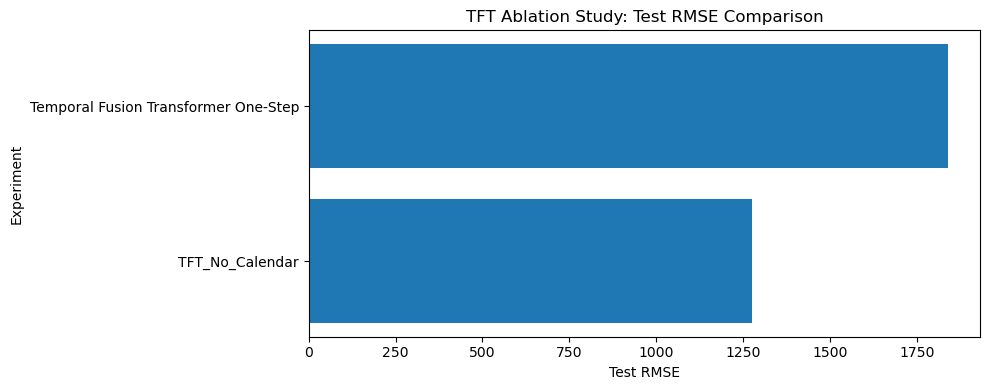

In [17]:
# ============================================================
# Plot Test RMSE Comparison
# ============================================================

plot_df = test_summary_df.dropna(subset=["RMSE"]).copy()

if not plot_df.empty:
    plot_df = plot_df.sort_values("RMSE", ascending=True)

    plt.figure(figsize=(10, max(4, 0.5 * len(plot_df))))
    plt.barh(plot_df["model"], plot_df["RMSE"])
    plt.xlabel("Test RMSE")
    plt.ylabel("Experiment")
    plt.title("TFT Ablation Study: Test RMSE Comparison")
    plt.tight_layout()
    plt.show()
else:
    print("No RMSE values available for plotting.")

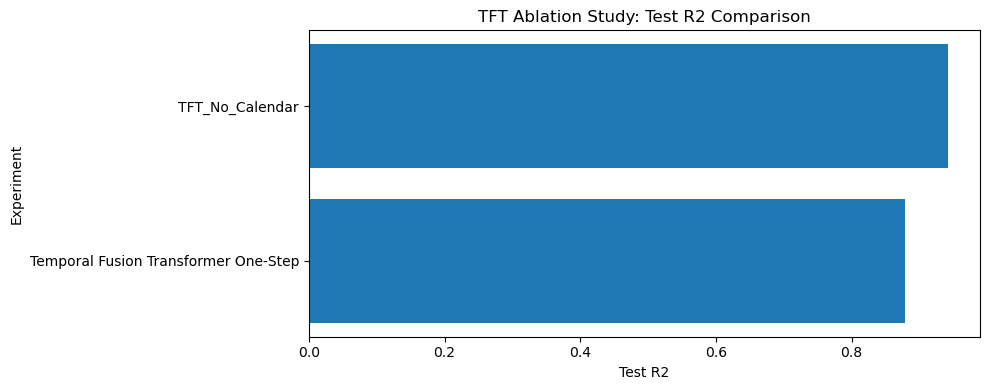

In [18]:
# ============================================================
# Plot Test R2 Comparison
# ============================================================

plot_df = test_summary_df.dropna(subset=["R2"]).copy()

if not plot_df.empty:
    plot_df = plot_df.sort_values("R2", ascending=True)

    plt.figure(figsize=(10, max(4, 0.5 * len(plot_df))))
    plt.barh(plot_df["model"], plot_df["R2"])
    plt.xlabel("Test R2")
    plt.ylabel("Experiment")
    plt.title("TFT Ablation Study: Test R2 Comparison")
    plt.tight_layout()
    plt.show()
else:
    print("No R2 values available for plotting.")

## How to Share This Notebook With Teammates

Set `CASES_TO_RUN` near the top of the notebook:

```python
CASES_TO_RUN = [2]        # teammate A: No Weather
CASES_TO_RUN = [3]        # teammate B: No Calendar
CASES_TO_RUN = [4]        # teammate C: No Holiday
CASES_TO_RUN = [5]        # teammate D: Target History Only
```

After each run, send back these files from `modeling_outputs/tft_ablation/`:

1. `<ExperimentName>_results.csv`
2. `<ExperimentName>_test_predictions.csv`
3. `<ExperimentName>_metadata.json`
4. `saved_models/<ExperimentName>.ckpt` if you also want to keep the trained ablation model.

For final aggregation, the most important file is `<ExperimentName>_results.csv`.